# Import libraries

In [36]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import ( LinearRegression, Ridge, Lasso, ElasticNet )
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

# Load dataset

In [24]:
# load the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Dataset exploration

In [26]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# Missing value checking

In [27]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

# No missing value is found in this dataset

# EDA (Exploratory Data Analysis)

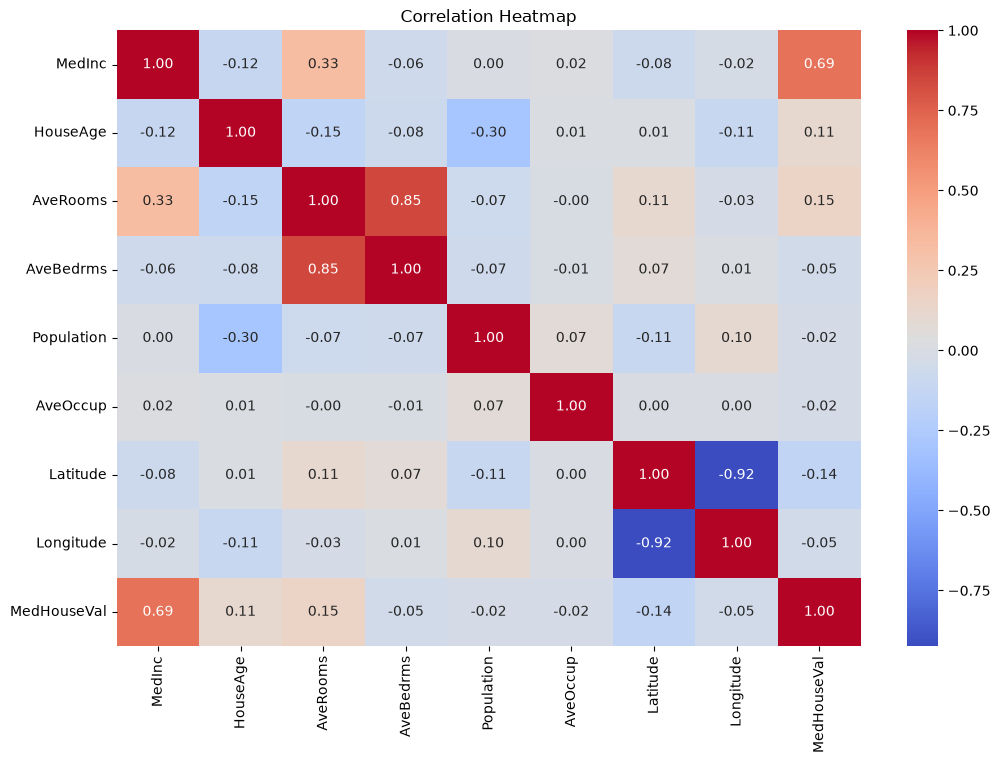

In [28]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

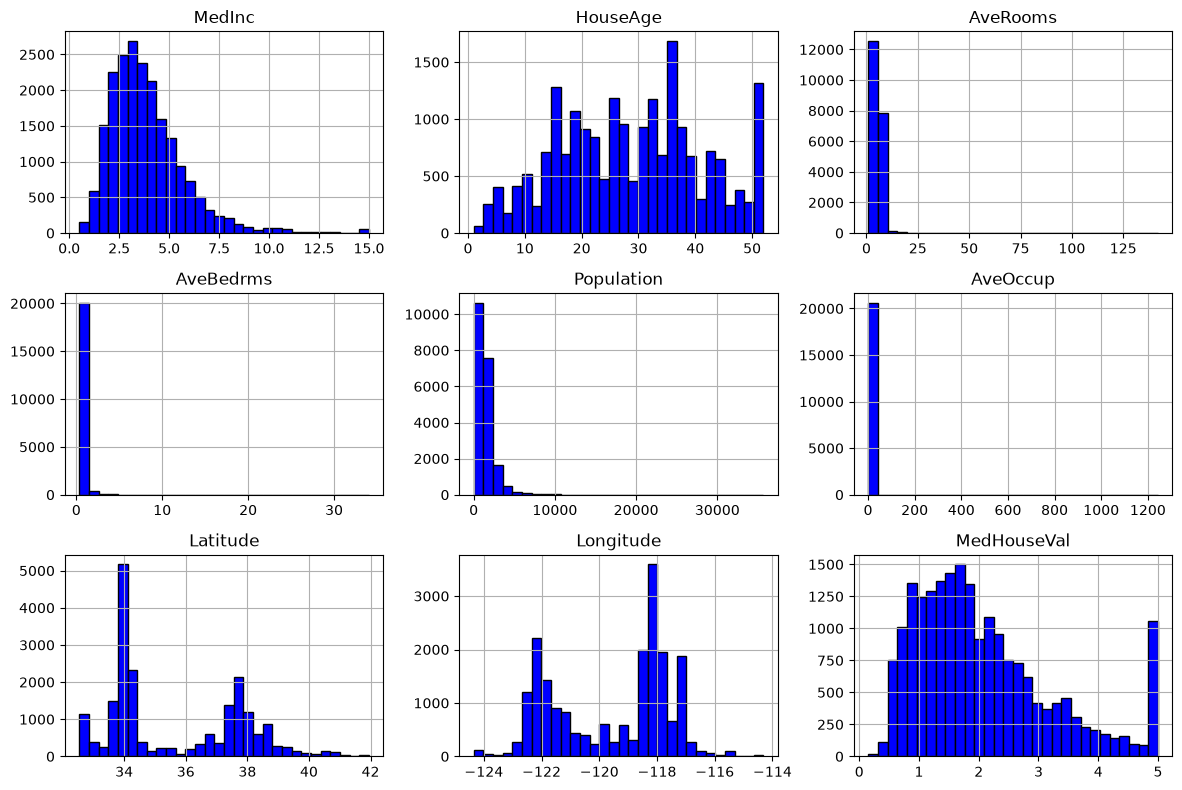

In [29]:
# Histogram
df.hist(bins=30, figsize=(12, 8), color='blue', edgecolor='black')
plt.tight_layout()
plt.show()

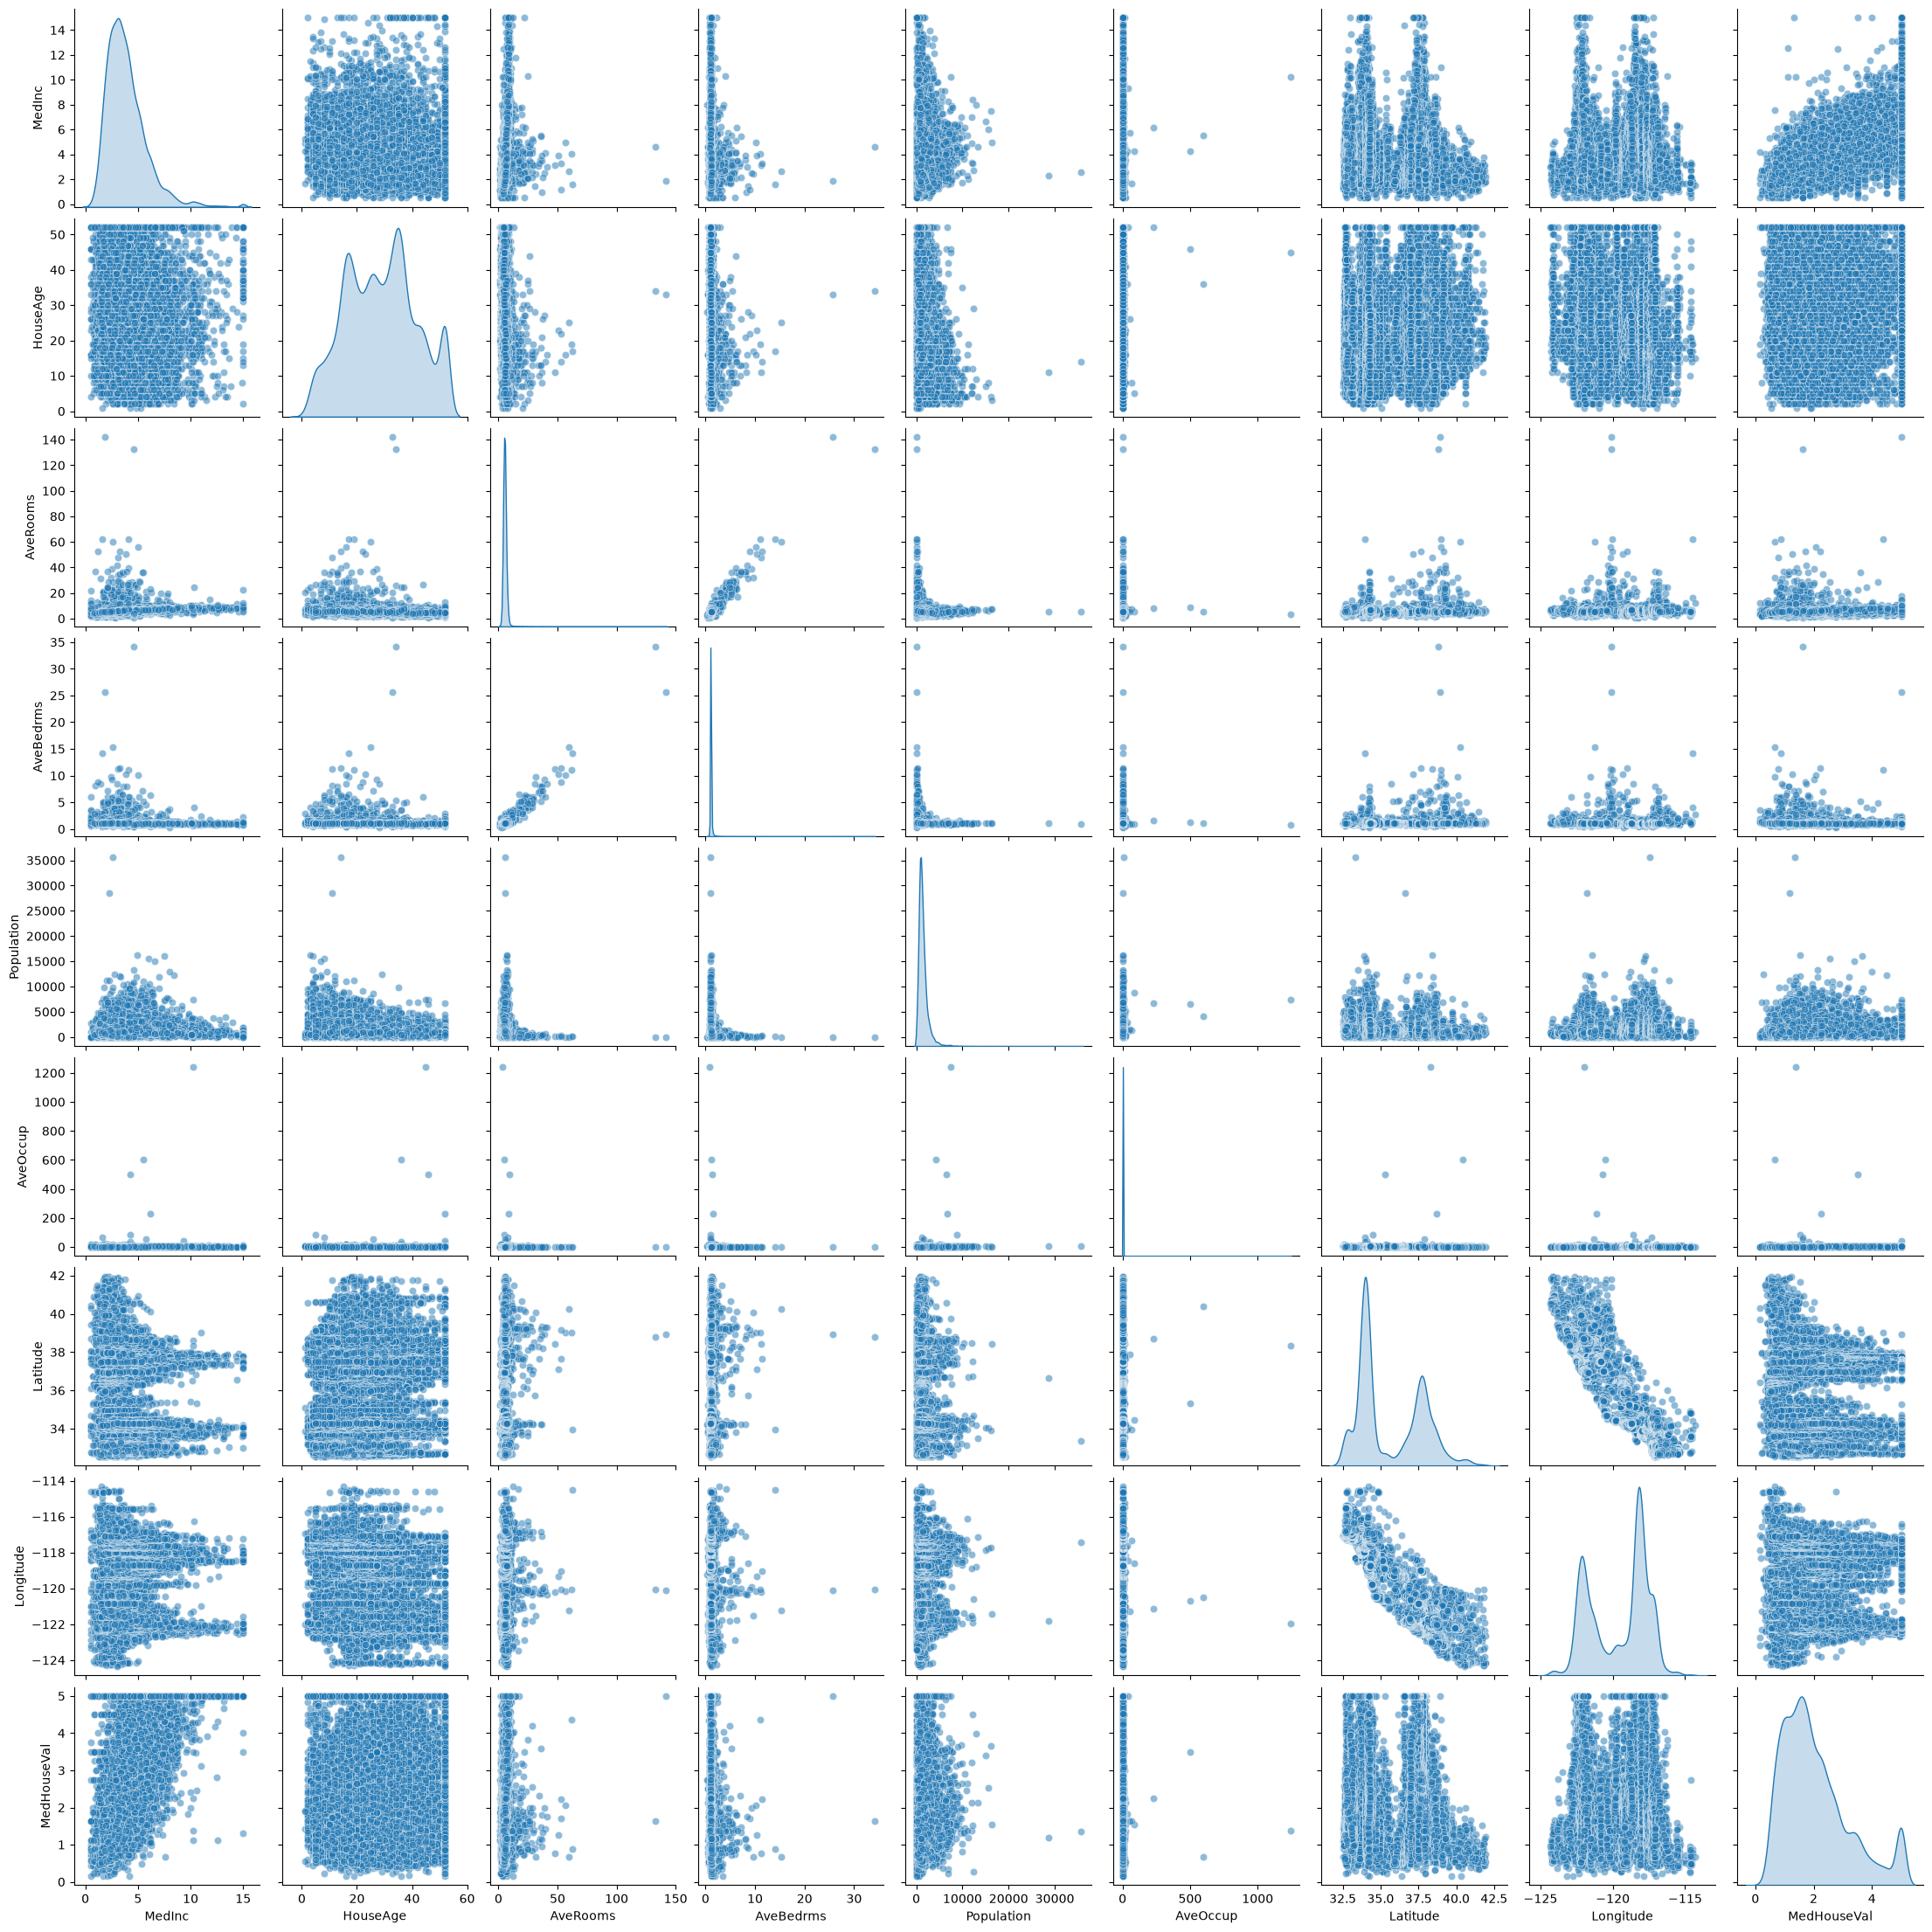

In [30]:
# Pairplot 
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

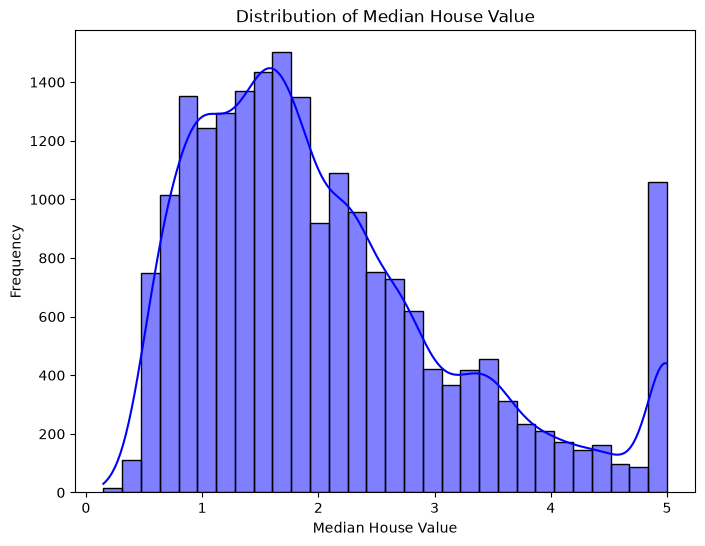

In [31]:
# Target distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['MedHouseVal'], bins=30, kde=True, color='blue', edgecolor='black')
plt.title("Distribution of Median House Value") 
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

# Select features and target

In [32]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-test spilt

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling

In [34]:
scaler = StandardScaler()

# Defining models

In [42]:
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(max_depth=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'xgboost': XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

# Train and evaluate models

In [43]:
results = []

for name, model in models.items():
    # Create a pipeline with scaling and the model
    pipeline = Pipeline([
        ('scaler', scaler),
        ('model', model)
    ])
    
    # Fit the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })

# Performance Comparison

In [44]:
comparison_df = pd.DataFrame(results, columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2 Score'])
comparison_df.sort_values(by='R2 Score', ascending=False, inplace=True)
comparison_df.head()

,Model,MSE,RMSE,MAE,R2 Score
6,xgboost,0.243600,0.493558,0.329739,0.814104
5,Random Forest,0.462833,0.680319,0.490481,0.646802
4,Decision Tree,0.524515,0.724234,0.522259,0.599732
1,Ridge,0.555855,0.745557,0.533193,0.575816
0,Linear,0.555892,0.745581,0.533200,0.575788


# Visualize model performance

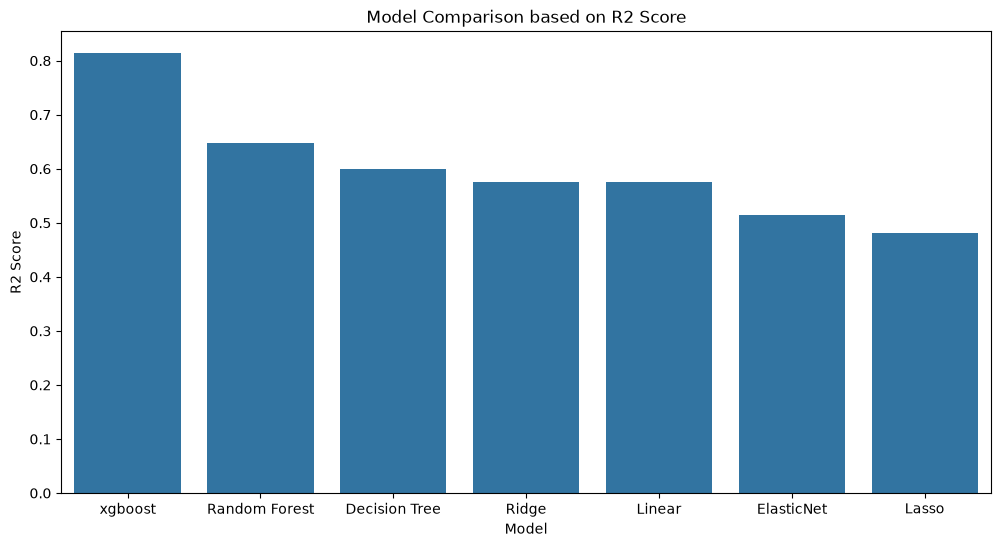

In [45]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Model', y="R2 Score")
plt.title("Model Comparison based on R2 Score")
plt.show()

# Residual analysis

Residual analysis evaluates the difference between observed and predicted values (residuals) to check how well a statistical model fits the data. 

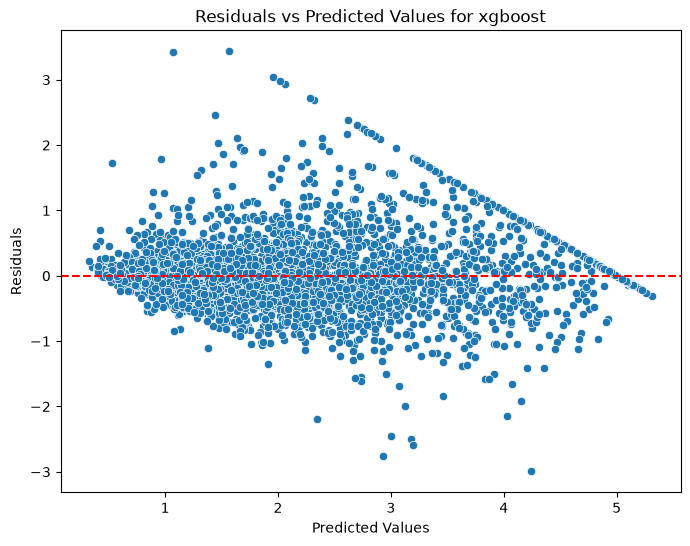

In [46]:
# Residual analysis for the best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]
best_pipeline = Pipeline([
    ('scaler', scaler),
    ('model', best_model)
])

y_pred_best = best_pipeline.predict(X_test)
residuals_best = y_test - y_pred_best

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_best, y=residuals_best)
plt.axhline(0, color='red', linestyle='--')
plt.title(f"Residuals vs Predicted Values for {best_model_name}")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# Actual vs predicted

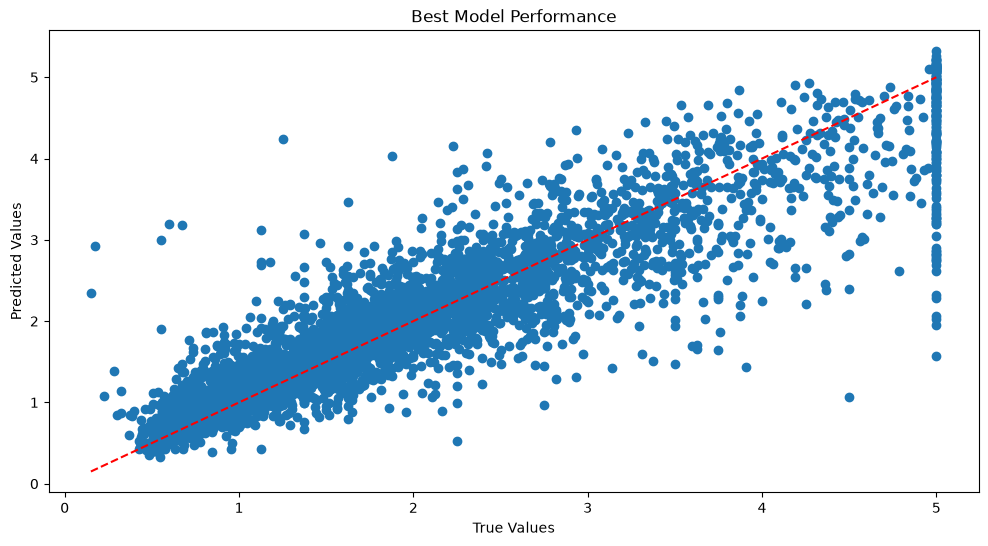

In [48]:
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Best Model Performance")
plt.show()

# Feature importance

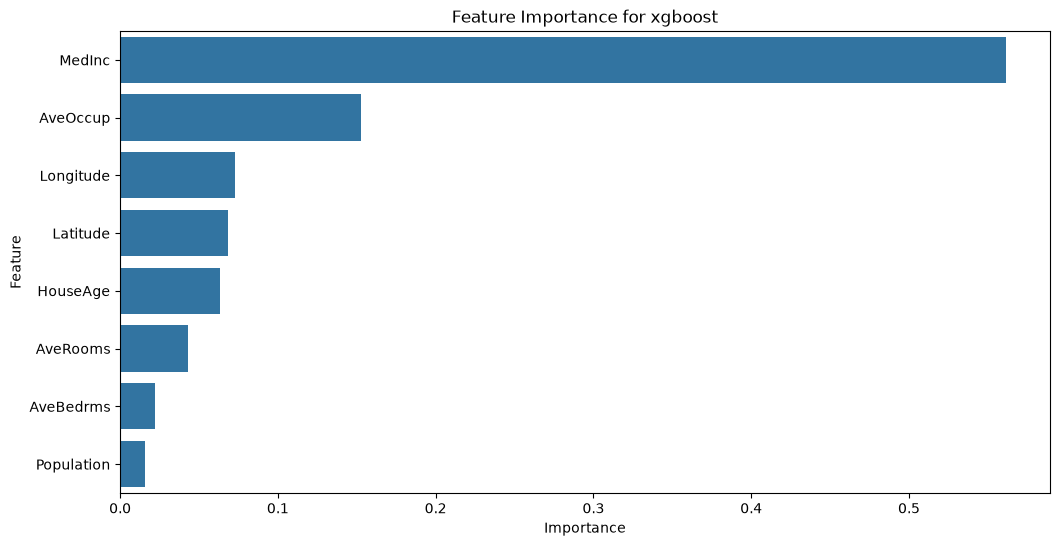

In [53]:
# feature importance for best model
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})


importances.sort_values(by='Importance', ascending=False, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=importances, x='Importance', y='Feature')
plt.title(f"Feature Importance for {best_model_name}")
plt.show()

# Model Comparison

| Model             | Strengths                                   | Weaknesses                                 |
| ----------------- | ------------------------------------------- | ------------------------------------------ |
| Linear Regression | Simple, interpretable, fast                 | Assumes linear relationships               |
| Ridge             | Reduces overfitting using L2 regularization | Requires tuning of alpha                   |
| Lasso             | Performs feature selection                  | Can remove useful correlated features      |
| ElasticNet        | Combines Ridge and Lasso benefits           | More hyperparameters                       |
| Decision Tree     | Captures non-linear patterns                | Can overfit                                |
| Random Forest     | Accurate, robust, handles non-linearity     | Less interpretable                         |
| XGBoost           | Excellent predictive performance            | More complex and computationally intensive |
